# 02 — Image preprocessing
Run 01_data_cleaning.ipynb first. This notebook reads its cleaned CSV and processes images when they are loaded. It does not write altered images or train a model.


## 1. Load cleaned metadata and set seeds
The CSV contains the original split and the new 0–10 target. Seeds make the initial random augmentation order reproducible when cells run in the same order.


In [ ]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
PROJECT = Path.cwd()
ROOT = PROJECT
CSV = ROOT / "DATASET" / "cleaned_top11_metadata.csv"
assert CSV.is_file(), "Run 01_data_cleaning.ipynb first from the project root."
df = pd.read_csv(CSV, dtype={"Image_ID": "string", "Class_Index": "string"})
assert set(df["Split"]) == {"train", "val", "test"}
assert set(df["Target"]) == set(range(11))
print("Cleaned rows:", len(df))
display(df[["Split", "Image_ID", "Disease", "Class_Index", "Target", "Image_Path"]].head())


## 2. Resolve paths and load RGB
Prefer Image_Path, Output_Path, Resolved_Source_Path and Source_Path in that order. PIL converts every loaded image to three RGB channels.


In [2]:
def resolve_image_path(row):
    for column in ["Image_Path", "Output_Path", "Resolved_Source_Path", "Source_Path"]:
        value = row.get(column)
        if pd.isna(value) or not str(value).strip():
            continue
        path = Path(str(value))
        choices = [path] if path.is_absolute() else [ROOT / path, PROJECT / path]
        for choice in choices:
            if choice.is_file():
                return choice
    fallback = ROOT / "DATASET" / str(row["Split"]) / f"Class_{row['Class_Index']}_{row['Disease']}" / f"{row['Image_ID']}.png"
    if fallback.is_file():
        return fallback
    raise FileNotFoundError(f"No image for {row['Split']} / {row['Image_ID']}")

sample_path = resolve_image_path(df.iloc[0])
with Image.open(sample_path) as file:
    sample_rgb = file.convert("RGB")
print("Example path:", sample_path)
print("Mode:", sample_rgb.mode, "| original size:", sample_rgb.size)


Example path: c:\Users\aravi\OneDrive\Desktop\coding\FYP MR disease classification\RFMiD_share\DATASET\train\Class_0_DR\1.png
Mode: RGB | original size: (2144, 1424)


## 3. Conservative fundus crop
A small grayscale copy locates pixels brighter than 8. Reject ambiguous masks or crops smaller than 40% of either original side; otherwise add a 3% margin. This only trims black surroundings.


In [3]:
def safe_fundus_crop(image, threshold=8, margin_fraction=0.03,
                     min_foreground_fraction=0.10, min_side_fraction=0.40):
    small = image.convert("L")
    small.thumbnail((512, 512))
    mask = np.asarray(small) > threshold
    if mask.mean() < min_foreground_fraction:
        return image
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return image
    width, height = image.size
    left = int(xs.min() * width / small.width)
    top = int(ys.min() * height / small.height)
    right = min(width, int((xs.max() + 1) * width / small.width))
    bottom = min(height, int((ys.max() + 1) * height / small.height))
    if (right - left) < min_side_fraction * width or (bottom - top) < min_side_fraction * height:
        return image
    margin_x, margin_y = int(width * margin_fraction), int(height * margin_fraction)
    box = (max(0, left - margin_x), max(0, top - margin_y),
           min(width, right + margin_x), min(height, bottom + margin_y))
    return image.crop(box)

cropped_sample = safe_fundus_crop(sample_rgb)
print("Original:", sample_rgb.size, "| cropped:", cropped_sample.size)


Original: (2144, 1424) | cropped: (1522, 1424)


## 4. Center on a black square and resize
Padding only extends the shorter side. Bicubic resizing then makes a 224 × 224 image without stretching the retinal field first.


Cropped: (1522, 1424) | padded: (1522, 1522) | resized: (224, 224)


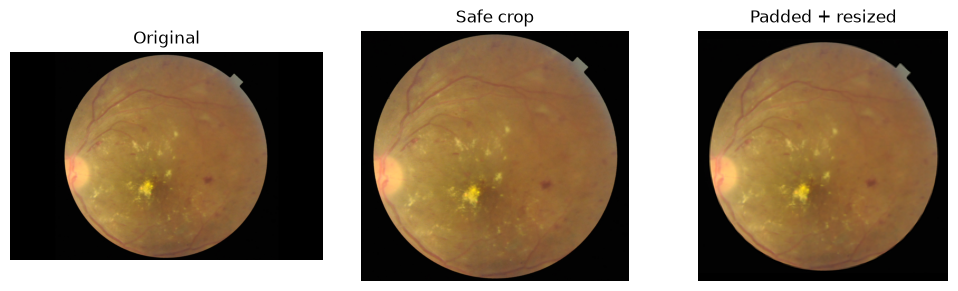

In [4]:
def square_pad(image):
    width, height = image.size
    side = max(width, height)
    canvas = Image.new("RGB", (side, side), (0, 0, 0))
    canvas.paste(image, ((side - width) // 2, (side - height) // 2))
    return canvas

padded_sample = square_pad(cropped_sample)
resized_sample = padded_sample.resize((224, 224), Image.Resampling.BICUBIC)
print("Cropped:", cropped_sample.size, "| padded:", padded_sample.size, "| resized:", resized_sample.size)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for axis, picture, title in zip(axes, [sample_rgb, cropped_sample, resized_sample], ["Original", "Safe crop", "Padded + resized"]):
    axis.imshow(picture)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()


## 5. Audit crop geometry and basic image quality
Inspect every cleaned image once. Geometry flags and simple brightness, contrast and sharpness flags are only prompts for visual review; they never remove records.


In [5]:
audit_rows = []
for _, row in df.iterrows():
    path = resolve_image_path(row)
    with Image.open(path) as file:
        image = file.convert("RGB")
    crop = safe_fundus_crop(image)
    width, height = image.size
    crop_width, crop_height = crop.size
    side = max(crop_width, crop_height)
    gray = np.asarray(crop.convert("L").resize((128, 128)), dtype=np.float32)
    brightness = float(gray.mean())
    contrast = float(gray.std())
    sharpness = float((np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()) / 2)
    visible_fraction = float((gray > 8).mean())
    retained = crop_width * crop_height / (width * height)
    aspect = crop_width / crop_height
    padding_fraction = 1 - crop_width * crop_height / (side * side)
    crop_flag = retained < 0.40 or not 0.50 <= aspect <= 2.0 or padding_fraction > 0.50
    quality_flag = brightness < 20 or brightness > 235 or contrast < 12 or sharpness < 2 or visible_fraction < 0.10
    audit_rows.append({"Split": row["Split"], "Image_ID": row["Image_ID"], "Disease": row["Disease"],
                       "original_width": width, "original_height": height,
                       "cropped_width": crop_width, "cropped_height": crop_height,
                       "original_area": width * height, "cropped_area": crop_width * crop_height,
                       "retained_area_fraction": retained, "cropped_aspect_ratio": aspect,
                       "padding_fraction": padding_fraction, "brightness": brightness,
                       "contrast": contrast, "sharpness": sharpness,
                       "visible_fraction": visible_fraction, "crop_flag": crop_flag,
                       "quality_flag": quality_flag})
inspection = pd.DataFrame(audit_rows)
crop_outliers = inspection.loc[inspection["crop_flag"]]
quality_flags = inspection.loc[inspection["quality_flag"]]
print("Images inspected:", len(inspection))
print("Crop outliers:", len(crop_outliers), "| quality flags:", len(quality_flags))
display(inspection.head(3))
display(crop_outliers.head(10))
display(quality_flags.head(10))


Images inspected: 1493
Crop outliers: 0 | quality flags: 98


,Split,Image_ID,Disease,original_width,original_height,cropped_width,cropped_height,original_area,cropped_area,retained_area_fraction,cropped_aspect_ratio,padding_fraction,brightness,contrast,sharpness,visible_fraction,crop_flag,quality_flag
0,train,1,DR,2144,1424,1522,1424,3053056,2167328,0.709888,1.068820,0.064389,84.608215,55.914902,3.626661,0.713013,False,False
1,train,2,DR,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,86.484863,56.596664,4.080093,0.715027,False,False
2,train,3,DR,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,87.851868,57.822765,3.873216,0.713257,False,False


,Split,Image_ID,Disease,original_width,original_height,cropped_width,cropped_height,original_area,cropped_area,retained_area_fraction,cropped_aspect_ratio,padding_fraction,brightness,contrast,sharpness,visible_fraction,crop_flag,quality_flag


,Split,Image_ID,Disease,original_width,original_height,cropped_width,cropped_height,original_area,cropped_area,retained_area_fraction,cropped_aspect_ratio,padding_fraction,brightness,contrast,sharpness,visible_fraction,crop_flag,quality_flag
364,train,780,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,52.675415,33.834759,1.862266,0.712341,False,True
408,train,862,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,37.352539,28.211033,1.905666,0.710754,False,True
417,train,881,MH,2144,1424,1514,1424,3053056,2155936,0.706157,1.063202,0.059445,21.671021,19.328392,1.584861,0.706726,False,True
421,train,887,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,21.173767,13.576016,0.927811,0.708679,False,True
432,train,920,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,52.828430,34.216415,1.826249,0.712524,False,True
438,train,937,MH,2144,1424,1514,1424,3053056,2155936,0.706157,1.063202,0.059445,26.323242,21.187433,1.360667,0.708923,False,True
448,train,962,MH,2144,1424,1526,1424,3053056,2173024,0.711754,1.071629,0.066841,36.945862,37.718075,1.835507,0.706238,False,True
477,train,1019,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,60.998352,39.434807,1.846703,0.712280,False,True
500,train,1057,MH,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,36.329773,28.947536,1.413693,0.708801,False,True
517,train,1088,ODE,2144,1424,1518,1424,3053056,2161632,0.708022,1.066011,0.061924,30.783447,21.669746,1.902744,0.706909,False,True


Suspicious crop examples — none


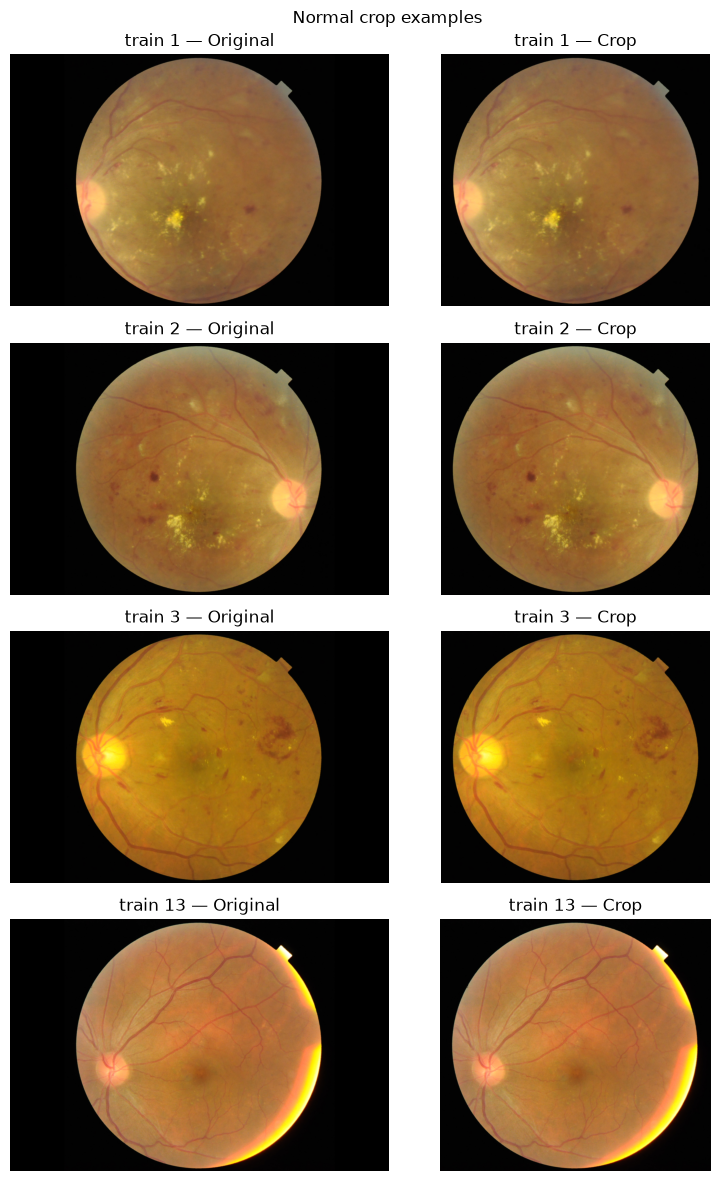

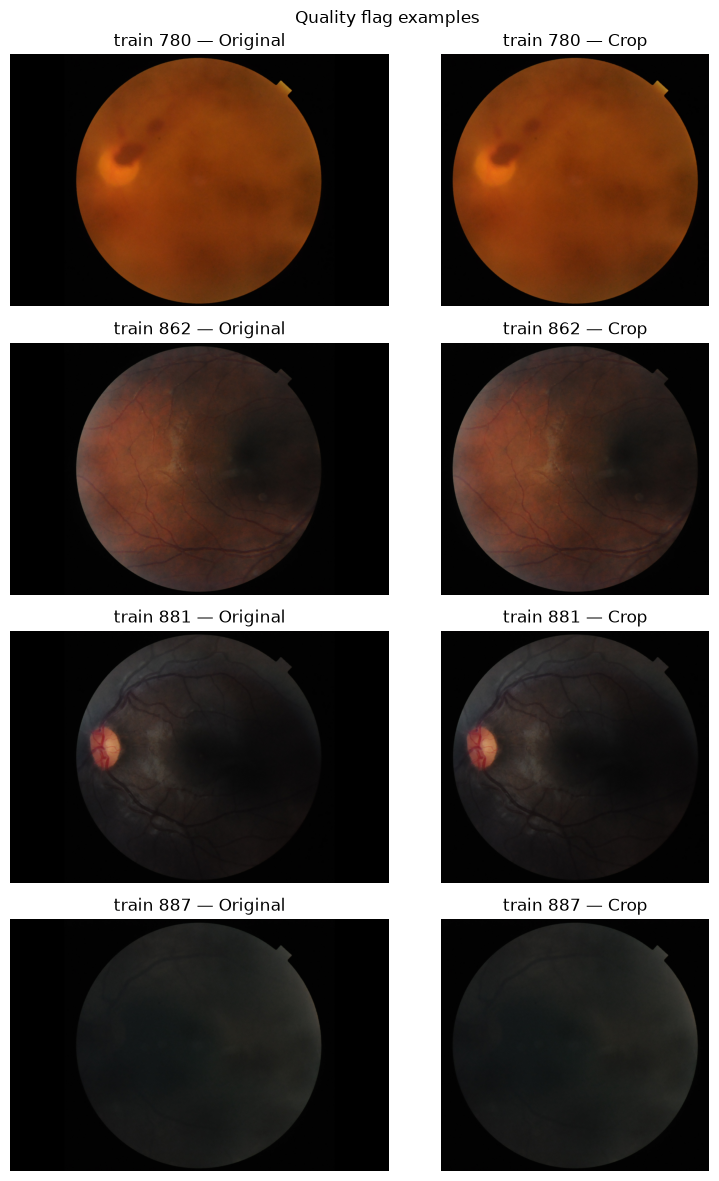

In [6]:
def preview_rows(rows, title, limit=4):
    if len(rows) == 0:
        print(title, "— none")
        return
    chosen = rows.head(limit)
    fig, axes = plt.subplots(len(chosen), 2, figsize=(8, 3 * len(chosen)), squeeze=False)
    for axes_row, (_, item) in zip(axes, chosen.iterrows()):
        record = df.loc[(df["Split"] == item["Split"]) & (df["Image_ID"] == item["Image_ID"])].iloc[0]
        with Image.open(resolve_image_path(record)) as file:
            original = file.convert("RGB")
        for axis, picture, label in zip(axes_row, [original, safe_fundus_crop(original)], ["Original", "Crop"]):
            axis.imshow(picture)
            axis.set_title(f"{item['Split']} {item['Image_ID']} — {label}")
            axis.axis("off")
    fig.suptitle(title)
    plt.tight_layout()

preview_rows(inspection.loc[~inspection["crop_flag"]], "Normal crop examples")
preview_rows(crop_outliers, "Suspicious crop examples")
preview_rows(quality_flags, "Quality flag examples")


## 6. Train and evaluation transforms
Apply four mild random changes only to training images. Validation and test use the same fixed RGB → crop → pad → resize → tensor → normalization sequence. These short functions use PIL and PyTorch directly.


In [7]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
mean_tensor = torch.tensor(MEAN, dtype=torch.float32).view(3, 1, 1)
std_tensor = torch.tensor(STD, dtype=torch.float32).view(3, 1, 1)

def to_normalized_tensor(image):
    tensor = torch.from_numpy(np.asarray(image, dtype=np.float32).copy()).permute(2, 0, 1) / 255.0
    return (tensor - mean_tensor) / std_tensor

def eval_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    return to_normalized_tensor(image)

def train_transform(image):
    image = safe_fundus_crop(image)
    image = square_pad(image)
    image = image.resize((224, 224), Image.Resampling.BICUBIC)
    if random.random() < 0.5:
        image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    image = image.rotate(random.uniform(-10, 10), resample=Image.Resampling.BICUBIC)
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.90, 1.10))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.90, 1.10))
    return to_normalized_tensor(image)
print("Input size: 224 x 224 | mean:", MEAN, "| std:", STD)
print("Train only: horizontal flip, ±10° rotation, mild brightness and contrast jitter")
print("Validation/test: deterministic crop, padding, resize and normalization")


Input size: 224 x 224 | mean: [0.485, 0.456, 0.406] | std: [0.229, 0.224, 0.225]
Train only: horizontal flip, ±10° rotation, mild brightness and contrast jitter
Validation/test: deterministic crop, padding, resize and normalization


## 7. Dataset and DataLoaders
Each item opens one image, converts it to RGB, applies its split's transform and returns the remapped integer target. Training is shuffled; validation and test retain CSV order.


In [8]:
class FundusDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(resolve_image_path(row)) as file:
            image = file.convert("RGB")
        image_tensor = self.transform(image)
        target = int(row["Target"])
        return image_tensor, target

train_dataset = FundusDataset(df.loc[df["Split"].eq("train")], train_transform)
val_dataset = FundusDataset(df.loc[df["Split"].eq("val")], eval_transform)
test_dataset = FundusDataset(df.loc[df["Split"].eq("test")], eval_transform)
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Dataset sizes:", {"train": len(train_dataset), "val": len(val_dataset), "test": len(test_dataset)})
print("Batch size:", BATCH_SIZE)


Dataset sizes: {'train': 911, 'val': 278, 'test': 304}
Batch size: 16


## 8. Check one batch from each split
Confirm shape, types, finite values and target range. Show de-normalized training pictures to inspect the complete preprocessing result.


train shape: (16, 3, 224, 224) image dtype: torch.float32 target dtype: torch.int64 finite: True
val shape: (16, 3, 224, 224) image dtype: torch.float32 target dtype: torch.int64 finite: True
test shape: (16, 3, 224, 224) image dtype: torch.float32 target dtype: torch.int64 finite: True


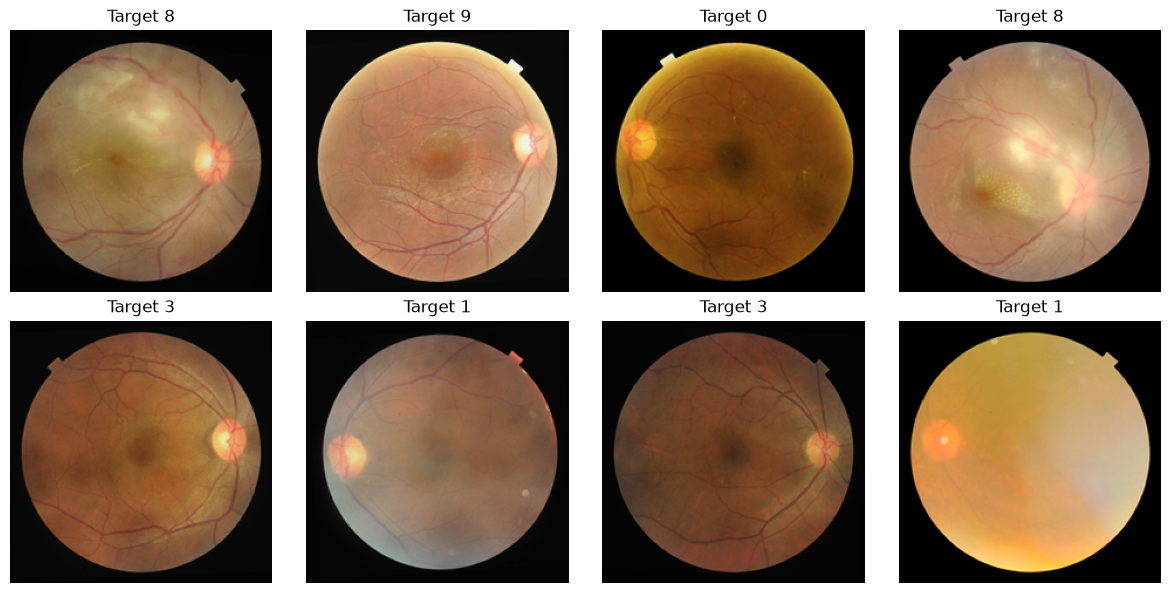

In [9]:
batches = {}
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    images, targets = next(iter(loader))
    batches[name] = (images, targets)
    assert images.ndim == 4 and images.shape[1:] == (3, 224, 224)
    assert images.shape[0] == targets.shape[0] and images.shape[0] <= BATCH_SIZE
    assert images.dtype == torch.float32 and targets.dtype == torch.int64
    assert torch.isfinite(images).all()
    assert targets.ge(0).all() and targets.le(10).all()
    print(name, "shape:", tuple(images.shape), "image dtype:", images.dtype,
          "target dtype:", targets.dtype, "finite:", bool(torch.isfinite(images).all()))

images, targets = batches["train"]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
mean = torch.tensor(MEAN).view(3, 1, 1)
std = torch.tensor(STD).view(3, 1, 1)
for axis, image, target in zip(axes.flat, images[:8], targets[:8]):
    picture = (image * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    axis.imshow(picture)
    axis.set_title(f"Target {int(target)}")
    axis.axis("off")
plt.tight_layout()


## 9. Reproducibility and final summary
Evaluation preprocessing should return identical tensors on repeated calls. Resetting the three seeds reproduces the first training transform call.


In [10]:
example = val_dataset[0][0]
print("Validation transform repeats exactly:", torch.equal(example, val_dataset[0][0]))
assert torch.equal(example, val_dataset[0][0])
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
first_train = train_dataset[0][0]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
second_train = train_dataset[0][0]
print("Seeded training transform repeats:", torch.equal(first_train, second_train))
assert torch.equal(first_train, second_train)
print("Input size: 224 x 224 | normalization mean:", MEAN, "std:", STD)
print("Training augmentation: horizontal flip, ±10° rotation, brightness ±10%, contrast ±10%")
print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Batch shapes:", {name: tuple(batch[0].shape) for name, batch in batches.items()})
print("Crop outliers:", len(crop_outliers), "| quality flags:", len(quality_flags))
print("Images and labels passed batch sanity checks.")


Validation transform repeats exactly: True
Seeded training transform repeats: True
Input size: 224 x 224 | normalization mean: [0.485, 0.456, 0.406] std: [0.229, 0.224, 0.225]
Training augmentation: horizontal flip, ±10° rotation, brightness ±10%, contrast ±10%
Dataset sizes: 911 278 304
Batch shapes: {'train': (16, 3, 224, 224), 'val': (16, 3, 224, 224), 'test': (16, 3, 224, 224)}
Crop outliers: 0 | quality flags: 98
Images and labels passed batch sanity checks.
